In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5

In [28]:
from catrace.response import run_response, RunResponseParams, load_all_dff
from catrace.visualize import PlotBoxplotByCondParams


In [29]:
from catrace.dataset import load_dataset_config
from catrace.stats import sort_conditions
config_file = '../dataset_configs/adult_dataset_t7.json'
dsconfig = load_dataset_config(config_file)
dff = load_all_dff(dsconfig)
dff = sort_conditions(dff.T, dsconfig.conditions).T

convert_to_rate = False

if convert_to_rate:
    dff = dff * dsconfig.frame_rate

Extracted_Data_mock1_Fish1 None
Extracted_Data_mock4_FishX None
Extracted_Data_mock5_FishX None
Extracted_Data_mock6_FishX None
Extracted_Data_mock8_FishY None
Extracted_Data_mockA10_FishX None
Extracted_Data_mockA10_FishY None
Extracted_Data_mockA10_fishZ None
Extracted_Data_Exp4_Fish3 None
Extracted_Data_Exp6_Fish1 None
Extracted_Data_Exp6_Fish4 None
Extracted_Data_Exp7_Fish3 None
Extracted_Data_Exp8_Fish1 None
Extracted_Data_Exp8_Fish4 None
Extracted_Data_ExpA10_Setup2_Fish1 None
Extracted_Data_ExpA10_Setup2_Fish2 None
Extracted_Data_ExpA10_Setup3_Fish1 None


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\process_time_trace.py:200: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(level='odor').mean()
C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\process_time_trace.py:200: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df.groupby(level='odor').mean()


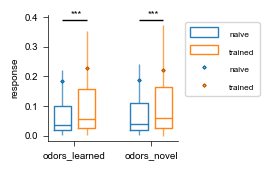

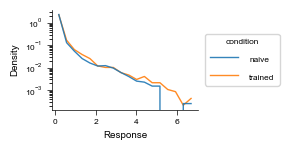

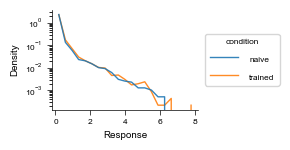

In [30]:
from catrace.response import RunResponseMultiCategoryParams, run_response_multi_category
from catrace.visualize import PlotBoxplotMultiOdorCondParams
colors = ['tab:blue', 'tab:orange'] #'tab:brown', 'tab:green', 'tab:pink']
boxplot_params = PlotBoxplotMultiOdorCondParams(
    figsize=(2.8, 1.8),
    do_plot_strip=False,
    #linewidth=1.0,
    mean_marker_size=0.5,
    box_linewidth=1,
    pvalue_marker_xoffset=0.02,)
    # box_colors=colors)
histplot_params = dict(
    binwidth=0.05 * dsconfig.frame_rate,
    log_scale=True,
    figsize=(3, 1.6),
    label_fontsize=7,
    tick_label_fontsize=6,
    colors = colors,
    linewidth=1,
    alpha=0.9,
)
params = RunResponseMultiCategoryParams(
    dff = dff,
    dsconfig = dsconfig,
    time_window = [47, 70],#[38, 63], #[37, 52],
    top_ratio = None,
    odor_keys = ['odors_learned', 'odors_novel'],
    boxplot_params = boxplot_params,
    histplot_params = histplot_params,
)

resp, test_results, output_figs = run_response_multi_category(params)
import json
#print(json.dumps(test_results, indent=4))

In [31]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results)
sentence.replace('odor_learned', 'learned odor').replace('odor_novel', 'novel odor')
print(sentence)

For odors_learned, Comparing naive (mean = 0.183 ± 0.49, n = 10328) vs trained (mean = 0.228 ± 0.55, n = 12184): Mann–Whitney U test, U = 53264456.00, P = 7.6 × 10^-88. For odors_novel, Comparing naive (mean = 0.188 ± 0.49, n = 10328) vs trained (mean = 0.220 ± 0.52, n = 12184): Mann–Whitney U test, U = 54573014.00, P = 4.1 × 10^-66.


In [32]:
from catrace.for_paper import save_figure_for_paper, save_stats_json
label_fontsize = 6
paper_fig_dir = '../../figures_for_paper'
dataset_name = 'BNP'
fig_name = f'{dataset_name}_response_boxplot'
fig = output_figs['fig_box']
ax = fig.get_axes()[0]
ax.set_ylabel('Mean spike probability', fontsize=label_fontsize)

xtick_labels = ax.get_xticklabels()
mapping = {
    'odors_learned': 'Conditioned',
    'odors_novel': 'Non-conditioned',
}
#if 'odors_learned' in xtick_labels:
try:
    new_labels = [mapping[label.get_text()] for label in xtick_labels]
    ax.set_xticklabels(new_labels, fontsize=6)
except:
    print('Could not set xtick labels')

# Set y tick label fontsize
ytick_labels = ax.get_yticklabels()
for label in ytick_labels:
    label.set_fontsize(5)

# Remove the legend
if ax.get_legend() is not None:
    ax.get_legend().remove()
# Set figure size
fig.set_size_inches(1.9, 1.55)
fig.tight_layout()

save_figure_for_paper(output_figs['fig_box'], fig_name, paper_fig_dir)
save_stats_json(test_results, fig_name, paper_fig_dir)

for odor_key, fig_hist in output_figs['hist_figs'].items():
    fig = fig_hist
    ax = fig.get_axes()[0]
    # Remove the legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    ax.set_xlabel('Mean spike probability', fontsize=label_fontsize)
    ax.set_ylabel('Density', fontsize=label_fontsize)
    import numpy as np
    ax.set_xlim(np.array([0, 1]) * dsconfig.frame_rate)

    # Set x tick label fontsize
    xtick_labels = ax.get_xticklabels()
    for label in xtick_labels:
        label.set_fontsize(5)
    # Set figure size
    fig.set_size_inches(1.9, 1.55)
    fig.tight_layout()
    fig_name = f'{dataset_name}_response_{odor_key}_histplot'
    save_figure_for_paper(fig_hist, fig_name, paper_fig_dir)


C:\Users\hubob\AppData\Local\Temp\ipykernel_30448\1697582959.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=6)


In [ ]:
# Save result data to CSV
import os


figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure09')
os.makedirs(save_dir, exist_ok=True)

resp.reset_index().to_csv(os.path.join(save_dir, 'extended_figure09bc_adult_single_neuron_response_to_odor.csv'), index=False)